In [ ]:
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.stats as ss

# магия для того, чтобы графики рисовались в векторном формате
from matplotlib_inline.backend_inline import set_matplotlib_formats
set_matplotlib_formats('svg')

In [ ]:
# import aesara.tensor as at
az.style.use("arviz-darkgrid")
rng = np.random.default_rng(7)

# Фитим вкшные лайки

In [ ]:
vk = pd.read_csv('https://stepik.org/media/attachments/lesson/1233589/vk_likes.csv')
vk = vk[(vk['VIEW'] > 0) & (vk['VIEW'] < 800)]

In [ ]:
vk2 = vk.iloc[:30]

### Определяем вероятностную модель

In [ ]:
# контейнер для параметров нашей вероятностной модели
bb_model = pm.Model()


with bb_model:
    # параметры нашего бета-биномиального распределения
    alpha = pm.HalfNormal('alpha', sigma=10)
    beta = pm.HalfNormal('beta', sigma=10)
    # p(\alpha, \beta) = p(\alpha) * p(\beta)
    # prior_alpha_beta = pm.Potential('p(alpha, beta)', pm.math.log((alpha + beta + 1) ** (-5/2)))

    # перепараметризация бета-распределения
    # mu = pm.Deterministic('mu', alpha / (alpha + beta))
    # v = pm.Deterministic('v', alpha + beta)
    # E(p | \alpha, \beta) =  \mu
    # D(p | \alpha, \beta) = \mu (1 - \mu) / v

    # вектор лайков из вектор p-шек(~ Beta)
    # p = pm.Beta('p',  alpha=alpha, beta=beta, shape=vk.shape[0])
    # likes = pm.Binomial('likes', p=p, n=vk['VIEW'], observed=vk['LIKE'])

    # вектор лайков из бета-биномиального распределения
    likes = pm.BetaBinomial('likes', alpha=alpha, beta=beta, n=vk['VIEW'], observed=vk['LIKE'])

    # сэмплим из апостериорного распределения.
    # trace = pm.sample(draws=1000, chains=2, random_seed=rng)

In [ ]:
# граф вероятностной модели
pm.model_to_graphviz(bb_model)

## Семплим


In [ ]:
with bb_model:
  trace = pm.sample(draws=1000, chains=2, random_seed=rng)

 Progress                    Draws   Divergences   Step size   Grad evals   Sampling Speed   Elapsed   Remaining  
 ───────────────────────────────────────────────────────────────────────────────────────────────────────────────── 
  ━━━━━━━━━━━━━━━━━━━━━━━━━   1999    0             0.436       1            14.95 drawss/s   0:02:13   0:00:00    
  ━━━━━━━━━━━━━━━━━━━━━━━━━   1999    0             0.666       7            7.09 drawss/s    0:04:41   0:00:00

## Визуализируем с [ArviZ](https://python.arviz.org/en/stable/)

In [ ]:
trace

Inference data with groups:
	> posterior
	> sample_stats
	> observed_data

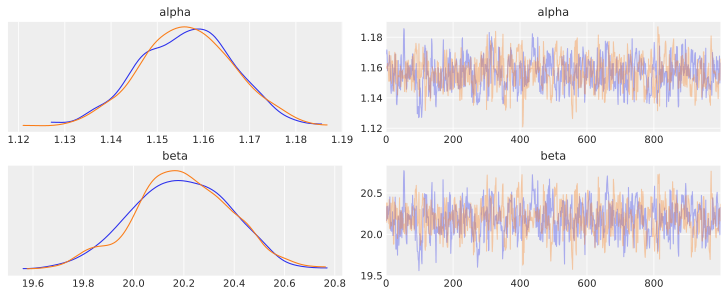

In [ ]:
az.plot_trace(trace, var_names=['alpha', 'beta'], figsize = (10, 4), compact=False)
plt.show()

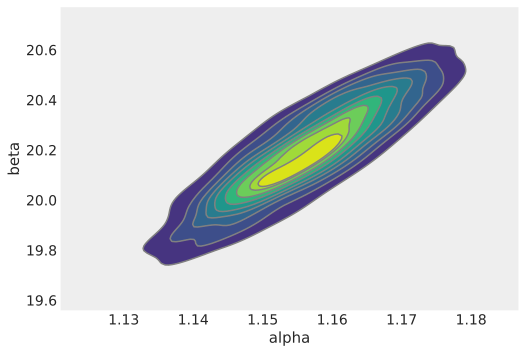

In [ ]:
az.plot_pair(trace, var_names=['alpha', 'beta'], kind='kde',
             kde_kwargs={'hdi_probs': np.linspace(0.1, 0.9, 9)}
             )
plt.show()

In [ ]:
# az.plot_pair(trace, var_names=['mu', 'v'], kind='kde')
# plt.show()

## Summary

In [ ]:
trace.posterior['μ'] = trace.posterior.alpha / (trace.posterior.alpha + trace.posterior.beta)
trace

Inference data with groups:
	> posterior
	> sample_stats
	> observed_data

In [ ]:
pm.summary(trace, var_names=['alpha', 'beta'])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,1.156,0.010,1.138,1.176,0.000,0.000,489.0,551.0,1.00
beta,20.190,0.197,19.784,20.522,0.009,0.006,485.0,672.0,1.01


#### Кастомные статистики

In [ ]:
pm.summary(trace,
           var_names=['alpha', 'beta'],
           stat_focus="median"
)

,median,mad,eti_3%,eti_97%,mcse_median,ess_median,ess_tail,r_hat
alpha,1.157,0.007,1.137,1.175,0.001,643.053,551.0,1.00
beta,20.187,0.131,19.801,20.541,0.010,654.662,672.0,1.01


In [ ]:
def median_sd(x):
     median = np.percentile(x, 50)
     sd = np.sqrt(np.mean((x-median)**2))
     return sd

func_dict = {
     "std": np.std,
     "median_std": median_sd,
     "2.5%": lambda x: np.percentile(x, 2.5),
     "median": lambda x: np.percentile(x, 50),
     "97.5%": lambda x: np.percentile(x, 97.5),
}

pm.summary(trace,
           var_names=['alpha', 'beta'],
           stat_funcs=func_dict,
           extend=False
)

,std,median_std,2.5%,median,97.5%
alpha,0.010,0.010,1.137,1.157,1.176
beta,0.197,0.197,19.790,20.187,20.559


# Апостериорные делишки

In [ ]:
print("alpha_mean " , trace.posterior.alpha.values.mean())
pm.summary(trace, var_names=['alpha', 'beta'], round_to=6)

alpha_mean  1.1564076517042945


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,1.156408,0.010105,1.137650,1.175659,0.000458,0.000289,488.909661,550.893811,1.001322
beta,20.189829,0.196993,19.784279,20.522244,0.008951,0.005821,484.952790,672.277527,1.005715


In [ ]:
alpha = trace.posterior.alpha.values
beta = trace.posterior.beta.values
# И alpha, и beta имеют размер (2, 1000), но для np.quantile без указания осей это неважно
print(np.quantile(alpha / (alpha + beta), [0.025, 0.975]))

[0.05369626 0.05466798]


### Posterior Predictive

Давайте сгенерируем кучу реализаций вероятности лайка случайного пользователя
Beta(α,β), где (α,β)
берутся из апостериорного распределения. Это можно сделать с помощью метода pm.sample_posterior_predictive:



$q(p | D) = \int p(p|\alpha, \beta) p(\alpha, \beta | D) d\alpha d\beta$

$q(p | D) \approx \int p(p|\alpha, \beta) \delta_{(\alpha_{MAP}, \beta_{MAP})} d\alpha d\beta = p(p | \alpha_{MAP}, \beta_{MAP})  = Beta(p | \alpha_{MAP}, \beta_{MAP})$

In [ ]:
with pm.Model():
    alpha = pm.HalfFlat('alpha') # неважно, какое распределение тут указывать
    beta = pm.HalfFlat('beta')   #
    p = pm.Beta('p', alpha=alpha, beta=beta)
    # Таким образом мы можем получить 2000 сэмплов вероятности p: 2 цепочки по 1000 сэмплов.
    pp = pm.sample_posterior_predictive(trace, var_names=['p'])

pp

Sampling ... ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100% 0:00:00 / 0:00:00

Inference data with groups:
	> posterior_predictive

Если мы хотим сделать больше апостериорных сэмплов: например, по 10 на каждый сэмпл из trace, то можно «склонировать» trace в 10 раз вдоль какой-нибудь третей оси (сейчас их две: chain и draw):

In [ ]:
expanded_data = trace.posterior.expand_dims(dim={'z': 10})
with pm.Model():
    alpha = pm.HalfFlat('alpha')
    beta = pm.HalfFlat('beta')
    p = pm.Beta('p', alpha=alpha, beta=beta)
    # Таким образом мы можем получить 2000x10 сэмплов вероятности p: 2 цепочки по 1000 сэмплов по 10 "копиям"
    pp = pm.sample_posterior_predictive(expanded_data, var_names=['p'], sample_dims=['chain', 'draw', 'z']) # В этом случае обязательно нужно указывать все оси в параметре sample_dims!

pp

Sampling ... ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100% 0:00:00 / 0:00:00

Inference data with groups:
	> posterior_predictive

### Posterior distribution $p(\theta | D)$ vs. $\delta_{\theta_{MAP}}$

Давайте теперь нарисуем гистограмму и сравним ее с плотностью бета-распределения с параметрами 1.16 и 20.2 (это мода апостериорного распределения с прошлого шага):

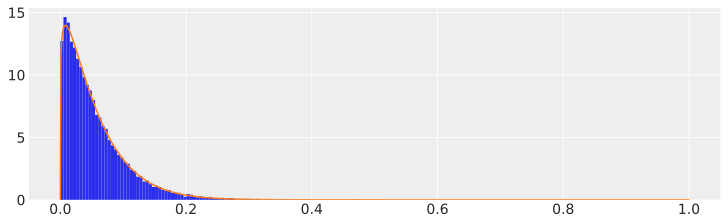

In [ ]:
plt.figure(figsize=(10, 3))

bins = np.linspace(0, 1, 200)
plt.hist(pp['posterior_predictive']['p'].values.ravel(), bins=bins, density=True)

x = np.linspace(0, 1, 1000)
# 1.16 и 20.2 (это мода апостериорного распределения с прошлого шага):
plt.plot(x, ss.beta(1.16, 20.2).pdf(x))
plt.show()

Как видно, разница как будто не очень существенна (если вообще есть).

> Это стандартная ситуация в случае «больших данных»: модель, в которой параметры берутся из апостериорного распределения, по качеству не отличается от модели в которой параметры это конкретные числа, которые максимизируют апостериорную плотность. В таких случаях они обычно очень похожи на параметры, которые максимизируют правдоподобие.

### Posterior Predictive Checks

Давайте теперь посмотрим, насколько наша модель качественно работает.

Одна из основных целей анализа пользовательских лайков и просмотров заключается в том, чтобы оценивать среднюю вероятность лайка по всем пользователям и проверять с помощью AB-тестов, как она изменилась при тех или иных изменениях продукта.  
В частности, кажется мега желательным,  
 чтобы апостериорное   распределение `(vk['LIKE'] / vk['VIEW']).mean()` накрывало значение, которое мы можем посчитать по нашим данным. Давайте это проверим:

Sampling ... ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100% 0:00:00 / 0:00:24

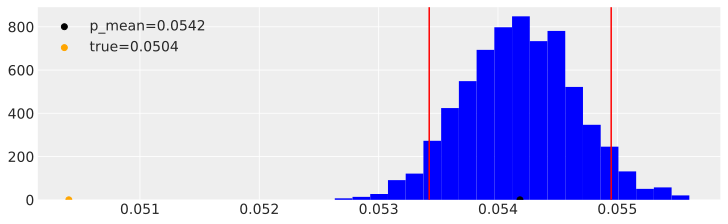

In [ ]:
expanded_trace = trace.posterior.expand_dims(dim={'z': 1})
with pm.Model() as m:
    alpha = pm.HalfFlat('alpha')
    beta = pm.HalfFlat('beta')
    p = pm.Beta('p', alpha=alpha, beta=beta, shape=len(vk))
    likes = pm.Binomial('likes', n=vk['VIEW'], p=p)
    # указываем Deterministic в случаях, когда величина однозначно определяется через другие
    mean_est = pm.Deterministic('mean_est', (likes / vk['VIEW']).mean())
    pp_means = pm.sample_posterior_predictive(trace, var_names=['mean_est'])
    # pp_means = pm.sample_posterior_predictive(expanded_trace, var_names=['mean_est'], sample_dims=['chain', 'draw', 'z'])


plt.figure(figsize=(10, 3))
plt.hist(pp_means['posterior_predictive']['mean_est'].values.ravel(), bins=20, color='blue', density=True)

p_mean = pp_means['posterior_predictive']['mean_est'].values.mean()
plt.scatter([p_mean], [0], color='black', label=f'p_mean={p_mean:.4f}')

true = (vk['LIKE'] / vk['VIEW']).mean()
plt.scatter([true], [0], color='orange', label=f'true={true:.4f}')

plt.axvline(x=np.percentile(pp_means.posterior_predictive.mean_est.values, 5), color='red')
plt.axvline(x=np.percentile(pp_means.posterior_predictive.mean_est.values, 95), color='red')

plt.legend()
plt.show()

Опаньки...

Смещение на 7.5% в ситуации, когда изменение вероятности лайка на 10% может быть супер интересным с продуктовой точки зрения, это, мягко говоря, не предел мечтаний.

В целом нетрудно понять, что основная проблема модели заключается в предположении, что вероятность лайка не зависит от количества просмотров. Если поковыряться в данных, но можно заметить, что у пользователей, у которых совсем мало просмотров, вероятность лайка меньше, чем у остальных пользователей.

Скажем, если мы оставим только пользователей, у которых больше трех просмотров, то ситуация выправляется:


In [ ]:
vk1 = vk[vk['VIEW'] > 3]
print(len(vk1) / len(vk))

0.8483395696913003


Почти 15% пользователей имеют 3 просмотра или меньше!

Sampling ... ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100% 0:00:00 / 0:00:22

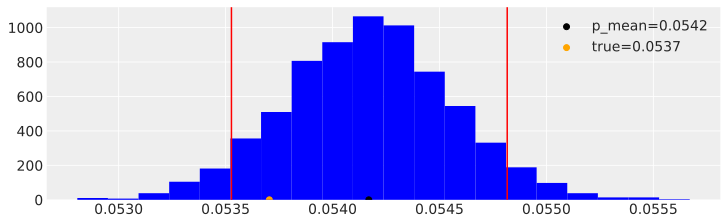

In [ ]:
expanded_trace = trace.posterior.expand_dims(dim={'z': 1})
with pm.Model() as m1:
    alpha = pm.HalfFlat('alpha')
    beta = pm.HalfFlat('beta')
    p = pm.Beta('p', alpha=alpha, beta=beta, shape=len(vk1))
    likes = pm.Binomial('likes', n=vk1['VIEW'], p=p)
    # указываем Deterministic в случаях, когда величина однозначно определяется через другие
    mean_est = pm.Deterministic('mean_est', (likes / vk1['VIEW']).mean())
    pp_means = pm.sample_posterior_predictive(trace, var_names=['mean_est'])
    # pp_means = pm.sample_posterior_predictive(expanded_trace, var_names=['mean_est'], sample_dims=['chain', 'draw', 'z'])


plt.figure(figsize=(10, 3))
plt.hist(pp_means['posterior_predictive']['mean_est'].values.ravel(), bins=20, color='blue', density=True)

p_mean = pp_means['posterior_predictive']['mean_est'].values.mean()
plt.scatter([p_mean], [0], color='black', label=f'p_mean={p_mean:.4f}')

true = (vk1['LIKE'] / vk1['VIEW']).mean()
plt.scatter([true], [0], color='orange', label=f'true={true:.4f}')

plt.axvline(x=np.percentile(pp_means.posterior_predictive.mean_est.values, 5), color='red')
plt.axvline(x=np.percentile(pp_means.posterior_predictive.mean_est.values, 95), color='red')

plt.legend()
plt.show()

Другое дело! Если брать пользователей с еще большим числом просмотров, их среднее будет все ближе к апостериорному среднему.

Как можно улучшить модель? Например, можно завести свое бета-биномиальное распределение для каждого из случаев одного, двух и трех просмотров соответственно. Таких пользователей в выборке много, поэтому мы наверняка сможем обучить что-нибудь вменяемое.

# Анализ чувствительности



## Prior Predictive Checks


### $p(\alpha, \beta) \propto (1 + \alpha + \beta)^{-\frac{5}{2}} $

In [ ]:
with pm.Model() as model1:
    alpha = pm.HalfFlat('alpha')
    beta = pm.HalfFlat('beta')
    pm.Potential('p(alpha, beta)', pm.math.log((1 + alpha + beta) ** (-5/2)))
    # likes = pm.BetaBinomial('likes', alpha=alpha, beta=beta, n=vk1['VIEW'], observed=vk1['LIKE'])

pm.model_to_graphviz(model1)

NotImplementedError: Cannot sample from half_flat variable
Apply node that caused the error: half_flat_rv{"->()"}(RNG(<Generator(PCG64) at 0x7930386F03C0>), NoneConst{None})
Toposort index: 0
Inputs types: [RandomGeneratorType, <pytensor.tensor.type_other.NoneTypeT object at 0x793057ffc440>]
Inputs shapes: ['No shapes', 'No shapes']
Inputs strides: ['No strides', 'No strides']
Inputs values: [Generator(PCG64) at 0x7930386F03C0, None]
Outputs clients: [[], [Shape(alpha)]]

Backtrace when the node is created (use PyTensor flag traceback__limit=N to make it longer):
  File "/usr/local/lib/python3.12/dist-packages/IPython/core/async_helpers.py", line 78, in _pseudo_sync_runner
    coro.send(None)
  File "/usr/local/lib/python3.12/dist-packages/IPython/core/interactiveshell.py", line 3257, in run_cell_async
    has_raised = await self.run_ast_nodes(code_ast.body, cell_name,
  File "/usr/local/lib/python3.12/dist-packages/IPython/core/interactiveshell.py", line 3473, in run_ast_nodes
    if 

In [ ]:
with pm.Model() as model1:
    alpha = pm.HalfFlat('alpha')
    beta = pm.HalfFlat('beta')
    pm.Potential('p(alpha, beta)', pm.math.log((1 + alpha + beta) ** (-5/2)))

    ppc_trace1 = pm.sample(draws=100)


ppc_trace1

In [ ]:
alphas = ppc_trace1.posterior['alpha'].values[0]
betas = ppc_trace1.posterior['beta'].values[0]
x = np.linspace(0, 1, 1000)

plt.figure(figsize=(10, 3))
for a, b in zip(alphas, betas):
    plt.plot(x, ss.beta(a, b).pdf(x), color='blue', alpha=0.8, linewidth=0.5)
plt.ylim([0, 20])
plt.show()

In [ ]:
with model1:
  likes = pm.BetaBinomial('likes', alpha=alpha, beta=beta, n=vk1['VIEW'], observed=vk1['LIKE'])

pm.model_to_graphviz(model1)

In [ ]:
with pm.Model() as model1:
    alpha = pm.HalfFlat('alpha')
    beta = pm.HalfFlat('beta')
    pm.Potential('p(alpha, beta)', pm.math.log((1 + alpha + beta) ** (-5/2)))

    likes = pm.BetaBinomial('likes', alpha=alpha, beta=beta, n=vk1['VIEW'], observed=vk1['LIKE'])
    trace1 = pm.sample(chains=1)


ppc_trace1

In [ ]:
az.plot_pair(trace1, var_names=['alpha', 'beta'], kind='kde',
             kde_kwargs={'hdi_probs': np.linspace(0.1, 0.9, 9)}
             )
plt.show()

### $p(\alpha, \beta) \propto HN(\alpha|0, 10) \times HN(\beta|0, 10)$

In [ ]:
with pm.Model() as model0:
    alpha = pm.HalfNormal('alpha', sigma=10)
    beta = pm.HalfNormal('beta', sigma=10)
    likes = pm.BetaBinomial('likes', alpha=alpha, beta=beta, n=vk1['VIEW'], observed=vk1['LIKE'])

with model0:
  trace0 = pm.sample(chains=1)


pm.model_to_graphviz(model0)

In [ ]:
with model0:
  ppc_trace0 = pm.sample_prior_predictive(draws=100)


ppc_trace0

In [ ]:
alphas = ppc_trace0.prior['alpha'].values[0]
betas = ppc_trace0.prior['beta'].values[0]
x = np.linspace(0, 1, 1000)

plt.figure(figsize=(10, 3))
for a, b in zip(alphas, betas):
    plt.plot(x, ss.beta(a, b).pdf(x), color='blue', alpha=0.8, linewidth=0.5)
plt.ylim([0, 20])
plt.show()

In [ ]:
az.plot_pair(trace0, var_names=['alpha', 'beta'], kind='kde',
  kde_kwargs={'hdi_probs': np.linspace(0.1, 0.9, 9)}
)
plt.show()

Видим, что разницы практически нет. Это означает, что данных достаточно много, чтобы результат оставался тем же самым даже на неинформативных априорных распределениях.

> Если результат меняется при переходе от неинформативных распределений к разумным информативным (или слабо информативным), это означает, что у нас плохая модель (то есть плохая структура правдоподобия) или мало данных. Если с правдоподобием все ок, но мало данных, то роль априорного распределения повышается и приходится думать о том, как его выбирать